# Mixture Density Network with Player Embeddings

Train an MDN to predict throw destination distributions using:
- **Player embeddings** (learned representation of each player)
- **Field position** (thrower_x, thrower_y)

The model outputs parameters for a Gaussian Mixture Model with K components.

In [1]:
#%pip install umap-learn

In [2]:
import psycopg2
from psycopg2.extras import RealDictCursor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import joblib
import os

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Plot settings
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load Data from PostgreSQL

In [3]:
# Database connection
DB_CONFIG = {
    'dbname': 'ufa_analytics',
    'user': os.getenv('DB_USER', 'postgres'),
    'password': '',
    'host': 'localhost',
    'port': 5432
}

def get_db_connection():
    return psycopg2.connect(**DB_CONFIG, cursor_factory=RealDictCursor)

In [4]:
# Query all throw events (types 18, 19, 20, 22)
# DB stores physical coords: home attacks Y=110, away attacks Y=10.
# For model training, we normalize ALL throws to attack toward Y=110
# by flipping away team coordinates in the query.
conn = get_db_connection()
cur = conn.cursor()

query = """
SELECT
    e.thrower as player_id,
    CASE WHEN e.team = g.away_team_id THEN -e.thrower_x ELSE e.thrower_x END as thrower_x,
    CASE WHEN e.team = g.away_team_id THEN 120 - e.thrower_y ELSE e.thrower_y END as thrower_y,
    CASE WHEN e.team = g.away_team_id THEN
        CASE WHEN e.event_type IN (18,19,20) THEN -e.receiver_x ELSE -e.turnover_x END
    ELSE
        CASE WHEN e.event_type IN (18,19,20) THEN e.receiver_x ELSE e.turnover_x END
    END as dest_x,
    CASE WHEN e.team = g.away_team_id THEN
        CASE WHEN e.event_type IN (18,19,20) THEN 120 - e.receiver_y ELSE 120 - e.turnover_y END
    ELSE
        CASE WHEN e.event_type IN (18,19,20) THEN e.receiver_y ELSE e.turnover_y END
    END as dest_y,
    e.event_type
FROM events e
JOIN games g ON e.game_id = g.game_id
WHERE e.thrower IS NOT NULL
    AND e.event_type IN (18, 19, 20, 22)
    AND e.thrower_x IS NOT NULL
    AND (
        (e.event_type IN (18,19,20) AND e.receiver_x IS NOT NULL)
        OR (e.event_type = 22 AND e.turnover_x IS NOT NULL)
    )
ORDER BY e.event_id;
"""

cur.execute(query)
rows = cur.fetchall()
cur.close()
conn.close()

# Convert to DataFrame
df = pd.DataFrame(rows)

print(f"Total throw events: {len(df):,}")
print(f"\nEvent type breakdown:")
print(df['event_type'].value_counts().sort_index())
print(f"\nUnique players: {df['player_id'].nunique()}")

Total throw events: 412,114

Event type breakdown:
event_type
18    353733
19     30164
20      4212
22     24005
Name: count, dtype: int64

Unique players: 1822


## 2. Data Preprocessing

In [5]:
# Filter players with minimum number of throws
MIN_THROWS = 500

player_counts = df['player_id'].value_counts()
valid_players = player_counts[player_counts >= MIN_THROWS].index
df_filtered = df[df['player_id'].isin(valid_players)].copy()

print(f"Players with {MIN_THROWS}+ throws: {len(valid_players)}")
print(f"Total throws from qualified players: {len(df_filtered):,}")
print(f"Percentage of data retained: {(len(df_filtered) / len(df)) * 100:.1f}%")

Players with 500+ throws: 244
Total throws from qualified players: 243,773
Percentage of data retained: 59.2%


In [6]:
# Encode player IDs to integers
player_encoder = LabelEncoder()
df_filtered['player_encoded'] = player_encoder.fit_transform(df_filtered['player_id'])

n_players = len(player_encoder.classes_)
print(f"Number of players (vocabulary size): {n_players}")
print(f"Player ID range: [0, {n_players-1}]")

Number of players (vocabulary size): 244
Player ID range: [0, 243]


In [7]:
# Normalize coordinates to [0, 1]
df_filtered['thrower_x_norm'] = (df_filtered['thrower_x'] + 25) / 50  # [-25, 25] -> [0, 1]
df_filtered['thrower_y_norm'] = df_filtered['thrower_y'] / 120  # [0, 120] -> [0, 1]
df_filtered['dest_x_norm'] = (df_filtered['dest_x'] + 25) / 50
df_filtered['dest_y_norm'] = df_filtered['dest_y'] / 120

print("Coordinate normalization complete")
print(f"Thrower X range: [{df_filtered['thrower_x_norm'].min():.3f}, {df_filtered['thrower_x_norm'].max():.3f}]")
print(f"Thrower Y range: [{df_filtered['thrower_y_norm'].min():.3f}, {df_filtered['thrower_y_norm'].max():.3f}]")

Coordinate normalization complete
Thrower X range: [-0.033, 1.033]
Thrower Y range: [0.000, 0.833]


In [8]:
# Create feature and target arrays
# X: [player_id (int), thrower_x_norm, thrower_y_norm]
# y: [dest_x_norm, dest_y_norm]

X = df_filtered[['player_encoded', 'thrower_x_norm', 'thrower_y_norm']].values
y = df_filtered[['dest_x_norm', 'dest_y_norm']].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (243773, 3)
y shape: (243773, 2)


In [9]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")

Train set: 195,018 samples
Test set:  48,755 samples


## 3. Define MDN Model with Player Embeddings

In [10]:
class MDN_Embedding(nn.Module):
    """
    Mixture Density Network with player embeddings.
    
    Architecture:
    1. Embedding layer for player IDs
    2. Concatenate embeddings with position features
    3. Fully connected layers with dropout
    4. Output GMM parameters (means, stds, correlations, weights)
    """
    
    def __init__(self, n_players, embedding_dim=16, n_components=3, hidden_size=128, dropout=0.2):
        super(MDN_Embedding, self).__init__()
        
        self.n_players = n_players
        self.embedding_dim = embedding_dim
        self.n_components = n_components
        
        # Player embedding layer
        self.player_embedding = nn.Embedding(n_players, embedding_dim)
        
        # Input: embedding (16) + thrower_x (1) + thrower_y (1) = 18
        input_size = embedding_dim + 2
        
        # Fully connected layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)
        
        # Output layer for GMM parameters
        # For each component: mu_x, mu_y, log_sigma_x, log_sigma_y, rho, log_pi
        self.output_size = n_components * 6
        self.output = nn.Linear(hidden_size, self.output_size)
    
    def forward(self, x):
        """
        Args:
            x: [batch_size, 3] where x[:, 0] is player_id (int),
               x[:, 1] is thrower_x_norm, x[:, 2] is thrower_y_norm
        
        Returns:
            mu: [batch_size, n_components, 2] - means
            sigma: [batch_size, n_components, 2] - stds
            rho: [batch_size, n_components] - correlations
            pi: [batch_size, n_components] - mixture weights
        """
        # Extract player IDs and convert to long (required for embedding)
        player_ids = x[:, 0].long()
        
        # Get player embeddings
        player_emb = self.player_embedding(player_ids)  # [batch, embedding_dim]
        
        # Concatenate embeddings with position features
        pos_features = x[:, 1:3]  # [batch, 2]
        combined = torch.cat([player_emb, pos_features], dim=1)  # [batch, embedding_dim + 2]
        
        # Forward through FC layers with dropout
        h = F.relu(self.fc1(combined))
        h = self.dropout(h)
        h = F.relu(self.fc2(h))
        h = self.dropout(h)
        h = F.relu(self.fc3(h))
        
        # Output layer (no dropout before output)
        out = self.output(h)  # [batch, n_components * 6]
        
        # Reshape to [batch, n_components, 6]
        batch_size = x.size(0)
        out = out.view(batch_size, self.n_components, 6)
        
        # Extract GMM parameters
        mu = out[:, :, 0:2]  # [batch, K, 2]
        log_sigma = out[:, :, 2:4]  # [batch, K, 2]
        rho = torch.tanh(out[:, :, 4])  # [batch, K], constrained to [-1, 1]
        log_pi = out[:, :, 5]  # [batch, K]
        
        # Convert log_sigma to sigma
        sigma = torch.exp(log_sigma)
        
        # Normalize mixture weights with softmax
        pi = F.softmax(log_pi, dim=1)
        
        return mu, sigma, rho, pi

## 4. Loss Function and Training

In [11]:
def gaussian_2d(y, mu, sigma, rho):
    """
    2D Gaussian PDF for a batch of points.
    
    Args:
        y: [batch, 2] - target points
        mu: [batch, K, 2] - means
        sigma: [batch, K, 2] - stds
        rho: [batch, K] - correlations
    
    Returns:
        prob: [batch, K] - probability density for each component
    """
    y = y.unsqueeze(1)  # [batch, 1, 2]
    
    # Compute normalized distance
    norm_y = (y - mu) / sigma  # [batch, K, 2]
    
    # Bivariate Gaussian formula
    z = (norm_y[:, :, 0]**2 + norm_y[:, :, 1]**2 - 
         2 * rho * norm_y[:, :, 0] * norm_y[:, :, 1])
    
    # Normalization constant
    norm = 2 * np.pi * sigma[:, :, 0] * sigma[:, :, 1] * torch.sqrt(1 - rho**2 + 1e-10)
    
    # PDF
    prob = torch.exp(-z / (2 * (1 - rho**2 + 1e-10))) / norm
    
    return prob


def mdn_loss(y, mu, sigma, rho, pi):
    """
    Negative log-likelihood loss for MDN.
    
    Args:
        y: [batch, 2] - target
        mu, sigma, rho, pi: GMM parameters from forward pass
    
    Returns:
        loss: scalar
    """
    # Compute probability for each component
    prob = gaussian_2d(y, mu, sigma, rho)  # [batch, K]
    
    # Weight by mixture coefficients
    weighted_prob = pi * prob  # [batch, K]
    
    # Sum over components
    mixture_prob = torch.sum(weighted_prob, dim=1)  # [batch]
    
    # Negative log-likelihood
    nll = -torch.log(mixture_prob + 1e-10)  # Add epsilon for stability
    
    return torch.mean(nll)

In [12]:
def train_epoch(model, train_loader, optimizer):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        mu, sigma, rho, pi = model(batch_x)
        
        # Compute loss
        loss = mdn_loss(batch_y, mu, sigma, rho, pi)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def validate(model, val_loader):
    """Validate on validation set."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            mu, sigma, rho, pi = model(batch_x)
            loss = mdn_loss(batch_y, mu, sigma, rho, pi)
            total_loss += loss.item()
    
    return total_loss / len(val_loader)

## 5. Prepare Data Loaders

In [13]:
# Create datasets
train_dataset = TensorDataset(
    torch.FloatTensor(X_train),
    torch.FloatTensor(y_train)
)

test_dataset = TensorDataset(
    torch.FloatTensor(X_test),
    torch.FloatTensor(y_test)
)

# Create data loaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 3048
Test batches: 762


## 6. Initialize and Train Model

In [14]:
# Model hyperparameters
EMBEDDING_DIM = 16
N_COMPONENTS = 3        # Increased from 3 to 5 for more complex distributions
HIDDEN_SIZE = 128
DROPOUT = 0.2           # Dropout regularization
WEIGHT_DECAY = 0.0001   # L2 regularization
LEARNING_RATE = 0.001
EPOCHS = 500  # Early stopping will prevent overfitting

# Initialize model
model = MDN_Embedding(
    n_players=n_players,
    embedding_dim=EMBEDDING_DIM,
    n_components=N_COMPONENTS,
    hidden_size=HIDDEN_SIZE,
    dropout=DROPOUT
)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"Model initialized with {n_params:,} parameters")
print(f"\nHyperparameters:")
print(f"  Embedding dim: {EMBEDDING_DIM}")
print(f"  GMM components: {N_COMPONENTS}")
print(f"  Hidden size: {HIDDEN_SIZE}")
print(f"  Dropout: {DROPOUT}")
print(f"  Weight decay (L2): {WEIGHT_DECAY}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"\nModel architecture:")
print(model)

Model initialized with 41,682 parameters

Hyperparameters:
  Embedding dim: 16
  GMM components: 3
  Hidden size: 128
  Dropout: 0.2
  Weight decay (L2): 0.0001
  Learning rate: 0.001

Model architecture:
MDN_Embedding(
  (player_embedding): Embedding(244, 16)
  (fc1): Linear(in_features=18, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=128, out_features=18, bias=True)
)


In [15]:
# Optimizer and scheduler
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY  # L2 regularization (NEW)
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.7,      # Less aggressive reduction (was 0.5)
    patience=50,     # Wait longer before reducing (was 5)
    min_lr=1e-6      # Don't go below this LR
)

print(f"Optimizer: Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: ReduceLROnPlateau (factor={0.7}, patience={50})")

Optimizer: Adam (lr=0.001, weight_decay=0.0001)
Scheduler: ReduceLROnPlateau (factor=0.7, patience=50)


In [16]:
# Training loop with early stopping
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 50  # Stop if no improvement for 50 epochs

print("Starting training...\n")
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'LR':>10}")
print("-" * 50)

for epoch in range(EPOCHS):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate(model, test_loader)
    val_losses.append(val_loss)
    
    # Step scheduler
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"{epoch+1:6d} | {train_loss:12.4f} | {val_loss:12.4f} | {current_lr:10.6f}")
    
    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.4f}")
        # Restore best model
        model.load_state_dict(best_model_state)
        break

print("\nTraining complete!")
print(f"Final epochs trained: {len(train_losses)}")
print(f"Best validation loss: {best_val_loss:.4f}")

Starting training...

 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------
    10 |      -1.2936 |      -1.3054 |   0.001000
    20 |      -1.3149 |      -1.3153 |   0.001000
    30 |      -1.3202 |      -1.3354 |   0.001000
    40 |      -1.3223 |      -1.3403 |   0.001000
    50 |      -1.3257 |      -1.3467 |   0.001000
    60 |      -1.3265 |      -1.3398 |   0.001000
    70 |      -1.3269 |      -1.3373 |   0.001000
    80 |      -1.3283 |      -1.3437 |   0.001000
    90 |      -1.3295 |      -1.3447 |   0.001000
   100 |      -1.3314 |      -1.3431 |   0.001000
   110 |      -1.3309 |      -1.3302 |   0.001000
   120 |      -1.3314 |      -1.3531 |   0.001000
   130 |      -1.3331 |      -1.3309 |   0.001000
   140 |      -1.3328 |      -1.3436 |   0.001000
   150 |      -1.3325 |      -1.3404 |   0.001000
   160 |      -1.3330 |      -1.3181 |   0.001000
   170 |      -1.3332 |      -1.3390 |   0.001000

Early stopping at epoch 17

## 7. Plot Training Curves

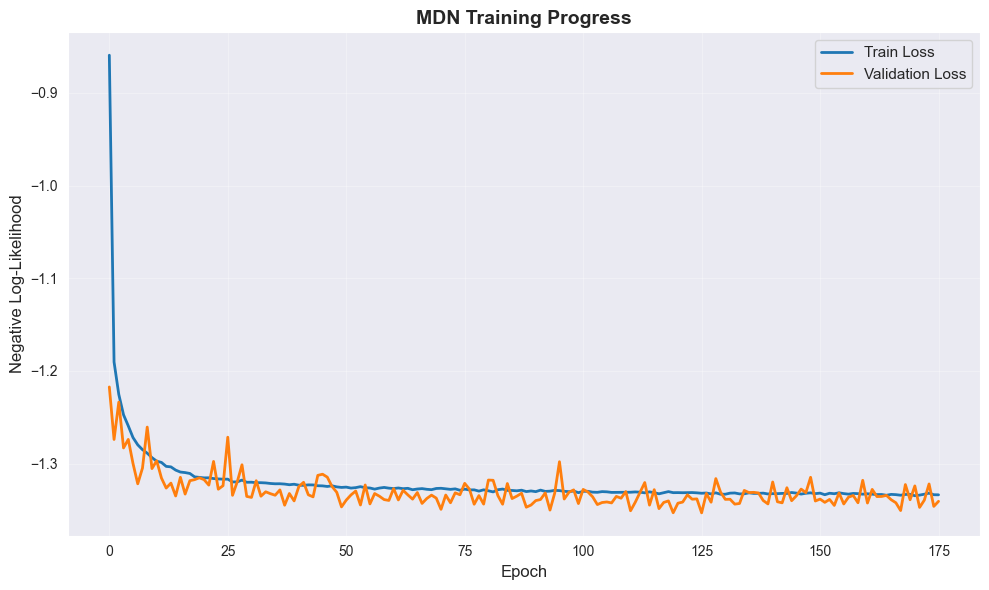

Final train loss: -1.3337
Final validation loss: -1.3407


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_losses, label='Train Loss', linewidth=2)
ax.plot(val_losses, label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Negative Log-Likelihood', fontsize=12)
ax.set_title('MDN Training Progress', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mdn_training_curve.png', dpi=150)
plt.show()

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")

## 8. Save Model and Encoder

In [18]:
# Create directory for saved models
os.makedirs('models', exist_ok=True)

# Save model state and metadata
model_path = 'models/mdn_embedding_model.pkl'

save_dict = {
    'model_state_dict': model.state_dict(),
    'n_players': n_players,
    'embedding_dim': EMBEDDING_DIM,
    'n_components': N_COMPONENTS,
    'hidden_size': HIDDEN_SIZE,
    'player_encoder': player_encoder,
    'train_losses': train_losses,
    'val_losses': val_losses
}

joblib.dump(save_dict, model_path)
print(f"✅ Model saved to {model_path}")

✅ Model saved to models/mdn_embedding_model.pkl


## 9. Test Predictions

In [19]:
def predict_throw_distribution(model, player_encoder, player_name, thrower_x, thrower_y, grid_size=20):
    """
    Predict throw distribution for a player at a position.
    
    Returns:
        grid: [grid_y, grid_x] probability distribution
        gmm_params: dict with GMM parameters
    """
    model.eval()
    
    # Encode player
    try:
        player_encoded = player_encoder.transform([player_name])[0]
    except:
        raise ValueError(f"Player '{player_name}' not in training data")
    
    # Normalize coordinates
    thrower_x_norm = (thrower_x + 25) / 50
    thrower_y_norm = thrower_y / 120
    
    # Create input tensor [player_id, x_norm, y_norm]
    x = torch.FloatTensor([[player_encoded, thrower_x_norm, thrower_y_norm]])
    
    # Predict GMM parameters
    with torch.no_grad():
        mu, sigma, rho, pi = model(x)
    
    # Convert to numpy
    mu = mu.squeeze(0).numpy()  # [K, 2]
    sigma = sigma.squeeze(0).numpy()  # [K, 2]
    rho = rho.squeeze(0).numpy()  # [K]
    pi = pi.squeeze(0).numpy()  # [K]
    
    # Denormalize means back to field coordinates
    mu_denorm = mu.copy()
    mu_denorm[:, 0] = mu[:, 0] * 50 - 25  # x
    mu_denorm[:, 1] = mu[:, 1] * 120  # y
    
    # Create probability grid
    x_bins = np.linspace(-25, 25, grid_size)
    y_bins = np.linspace(0, 120, int(grid_size * 2.4))  # Maintain aspect ratio
    
    grid = np.zeros((len(y_bins), len(x_bins)))
    
    # Evaluate GMM on grid
    for i, y_val in enumerate(y_bins):
        for j, x_val in enumerate(x_bins):
            # Normalize grid point
            x_norm = (x_val + 25) / 50
            y_norm = y_val / 120
            
            point = np.array([x_norm, y_norm])
            
            # Sum probability from all components
            prob = 0
            for k in range(len(pi)):
                # 2D Gaussian PDF
                diff = point - mu[k]
                cov = np.array([
                    [sigma[k, 0]**2, rho[k] * sigma[k, 0] * sigma[k, 1]],
                    [rho[k] * sigma[k, 0] * sigma[k, 1], sigma[k, 1]**2]
                ])
                
                det = np.linalg.det(cov)
                if det > 1e-10:  # Avoid singular matrices
                    norm_const = 2 * np.pi * np.sqrt(det)
                    exponent = -0.5 * diff @ np.linalg.inv(cov) @ diff
                    prob += pi[k] * np.exp(exponent) / norm_const
            
            grid[i, j] = prob
    
    gmm_params = {
        'means': mu_denorm.tolist(),
        'stds': (sigma * np.array([50, 120])).tolist(),  # Denormalize
        'correlations': rho.tolist(),
        'weights': pi.tolist()
    }
    
    return grid, gmm_params

In [20]:
def visualize_prediction(player_name, thrower_x, thrower_y):
    """Visualize predicted throw distribution for a player."""
    try:
        grid, gmm_params = predict_throw_distribution(
            model, player_encoder, player_name, thrower_x, thrower_y
        )
    except ValueError as e:
        print(f"Error: {e}")
        return
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Heatmap
    extent = [-25, 25, 0, 120]
    im = ax.imshow(grid, extent=extent, origin='lower', cmap='hot', alpha=0.7)
    
    # Mark thrower position
    ax.plot(thrower_x, thrower_y, 'bo', markersize=15, label='Thrower', zorder=10)
    
    # Mark GMM component means
    means = np.array(gmm_params['means'])
    weights = gmm_params['weights']
    for i, (mean, weight) in enumerate(zip(means, weights)):
        ax.plot(mean[0], mean[1], 'g*', markersize=20 * weight * 5,
                label=f'Mode {i+1} ({weight:.1%})', zorder=10)
    
    # Field markings
    ax.axhline(y=20, color='white', linestyle='--', alpha=0.5, linewidth=2, label='Goal line')
    ax.axhline(y=100, color='white', linestyle='--', alpha=0.5, linewidth=2)
    ax.axhline(y=60, color='white', linestyle=':', alpha=0.3, linewidth=2, label='Midfield')
    
    ax.set_xlim(-27, 27)
    ax.set_ylim(0, 120)
    ax.set_xlabel('Field X (meters)', fontsize=12)
    ax.set_ylabel('Field Y (meters)', fontsize=12)
    ax.set_title(f'{player_name} - Predicted Throws from ({thrower_x}, {thrower_y})',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    
    plt.colorbar(im, ax=ax, label='Probability Density')
    plt.tight_layout()
    plt.show()
    
    # Print GMM parameters
    print(f"\nGMM Parameters for {player_name} at ({thrower_x}, {thrower_y}):")
    print("="*60)
    for i in range(len(weights)):
        print(f"Component {i+1}:")
        print(f"  Mean: ({gmm_params['means'][i][0]:.1f}, {gmm_params['means'][i][1]:.1f})")
        print(f"  Std:  ({gmm_params['stds'][i][0]:.1f}, {gmm_params['stds'][i][1]:.1f})")
        print(f"  Correlation: {gmm_params['correlations'][i]:.3f}")
        print(f"  Weight: {weights[i]:.1%}")
        print()

In [21]:
# Get top player by throw count
top_players = player_counts.head(10)
print("Top 10 players by throw count:")
for player, count in top_players.items():
    print(f"  {player}: {count} throws")

Top 10 players by throw count:
  pjanas: 3220 throws
  aroy: 3072 throws
  bsadok: 2562 throws
  ataylor: 2518 throws
  srueschem: 2484 throws
  smott: 2413 throws
  jwilliams: 2386 throws
  jcubitt: 2383 throws
  echartock: 2286 throws
  emagsig: 2269 throws


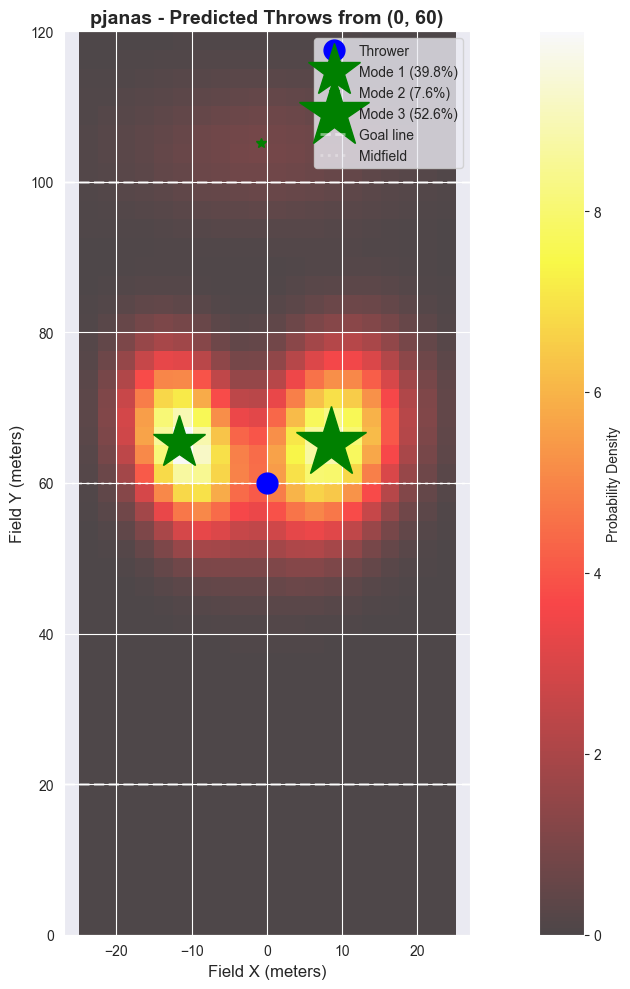


GMM Parameters for pjanas at (0, 60):
Component 1:
  Mean: (-11.6, 65.3)
  Std:  (5.1, 7.6)
  Correlation: -0.248
  Weight: 39.8%

Component 2:
  Mean: (-0.7, 105.2)
  Std:  (12.9, 6.5)
  Correlation: -0.000
  Weight: 7.6%

Component 3:
  Mean: (8.5, 65.3)
  Std:  (6.8, 8.3)
  Correlation: 0.215
  Weight: 52.6%



In [22]:
# Test prediction with top player from midfield
test_player = top_players.index[0]
visualize_prediction(test_player, thrower_x=0, thrower_y=60)

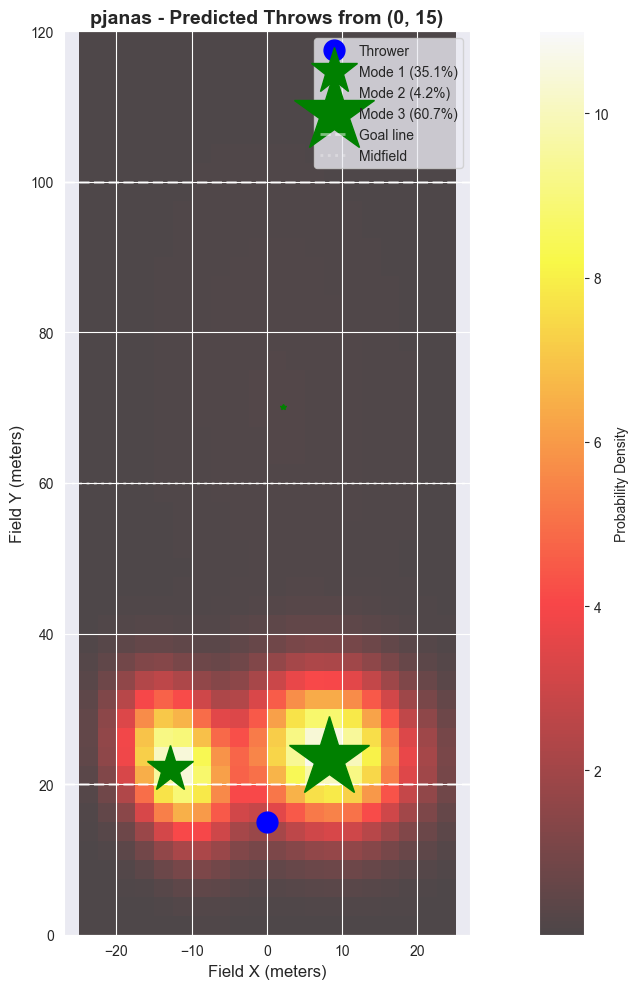


GMM Parameters for pjanas at (0, 15):
Component 1:
  Mean: (-12.8, 22.0)
  Std:  (4.9, 6.7)
  Correlation: -0.262
  Weight: 35.1%

Component 2:
  Mean: (2.2, 70.0)
  Std:  (12.3, 24.4)
  Correlation: -0.152
  Weight: 4.2%

Component 3:
  Mean: (8.3, 23.5)
  Std:  (7.7, 6.8)
  Correlation: -0.062
  Weight: 60.7%



In [23]:
# Test prediction from endzone
visualize_prediction(test_player, thrower_x=0, thrower_y=15)

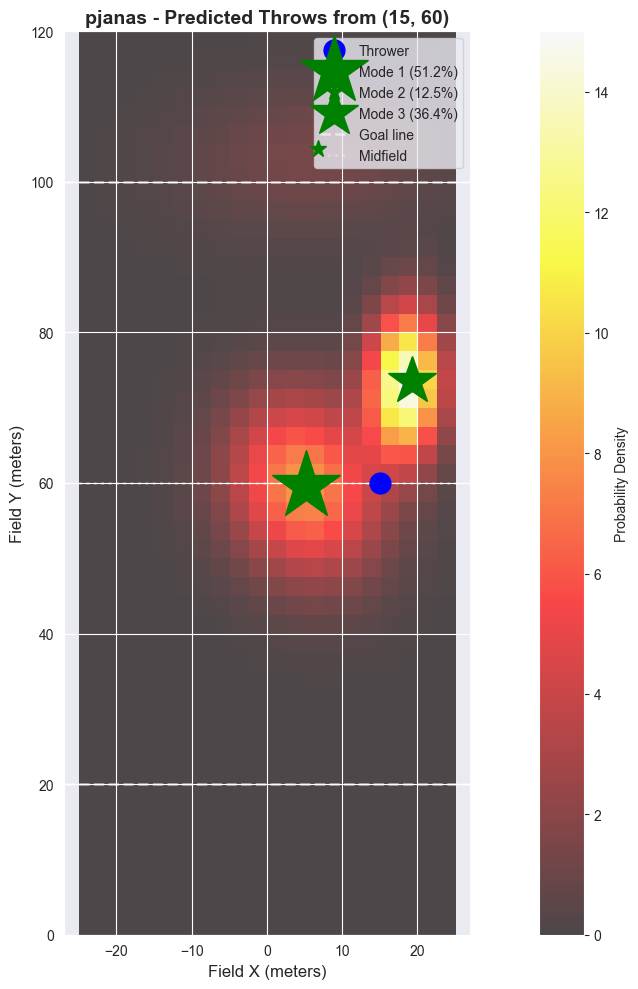


GMM Parameters for pjanas at (15, 60):
Component 1:
  Mean: (5.2, 59.6)
  Std:  (7.1, 8.5)
  Correlation: -0.118
  Weight: 51.2%

Component 2:
  Mean: (6.9, 104.3)
  Std:  (12.6, 6.9)
  Correlation: 0.112
  Weight: 12.5%

Component 3:
  Mean: (19.3, 73.6)
  Std:  (3.4, 6.7)
  Correlation: 0.024
  Weight: 36.4%



In [24]:
# Test prediction from sideline
visualize_prediction(test_player, thrower_x=15, thrower_y=60)

## 10. Analyze Player Embeddings

In [25]:
# Extract learned player embeddings
embeddings = model.player_embedding.weight.detach().numpy()
print(f"Player embeddings shape: {embeddings.shape}")
print(f"Each player is represented by a {EMBEDDING_DIM}-dimensional vector")

Player embeddings shape: (244, 16)
Each player is represented by a 16-dimensional vector


In [26]:
# Compare PCA, t-SNE, and UMAP for visualizing embeddings
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap  # pip install umap-learn if needed

# Extract embeddings
embeddings = model.player_embedding.weight.detach().numpy()

# 1. PCA (baseline)
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)
print(f"PCA - Explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# 2. t-SNE (good for local structure)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_tsne = tsne.fit_transform(embeddings)
print("t-SNE - Computed")

# 3. UMAP (best overall - preserves local AND global structure)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embeddings_umap = reducer.fit_transform(embeddings)
print("UMAP - Computed")

PCA - Explained variance: 27.7%
t-SNE - Computed


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP - Computed


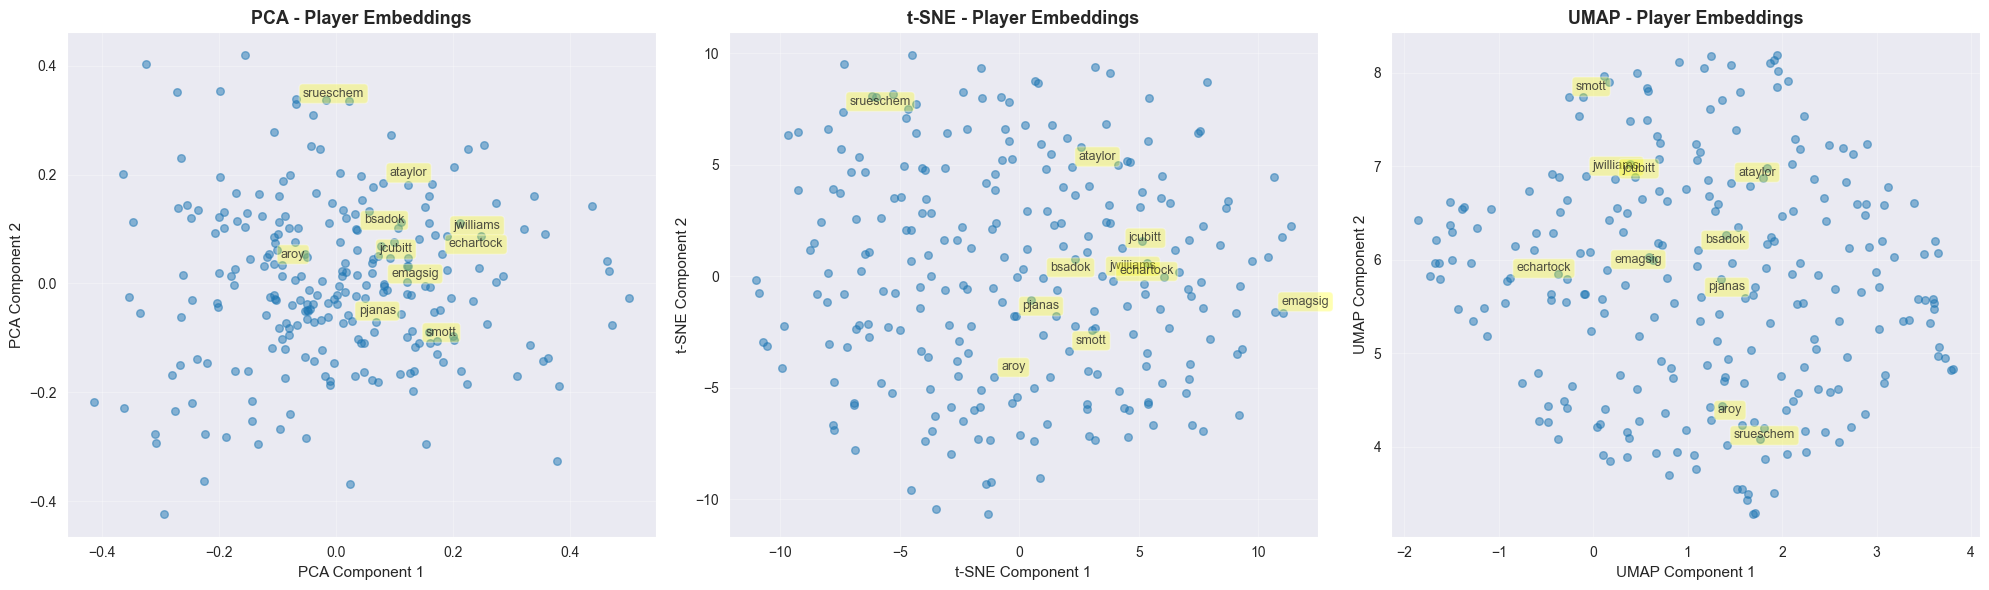


📊 Comparison:
• PCA: Linear, fast, shows global variance
• t-SNE: Non-linear, slower, great for finding clusters
• UMAP: Non-linear, fast, preserves local AND global structure (RECOMMENDED)

Look for clusters of similar players in the UMAP plot!


In [27]:
# Plot all three methods side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

methods = [
    ('PCA', embeddings_pca, axes[0]),
    ('t-SNE', embeddings_tsne, axes[1]),
    ('UMAP', embeddings_umap, axes[2])
]

for method_name, embeddings_2d, ax in methods:
    # Scatter all players
    ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, s=30)
    
    # Label top 10 players
    for i, player in enumerate(top_players.index[:10]):
        player_idx = player_encoder.transform([player])[0]
        ax.annotate(
            player, 
            xy=(embeddings_2d[player_idx, 0], embeddings_2d[player_idx, 1]),
            xytext=(5, 5), 
            textcoords='offset points',
            fontsize=9, 
            alpha=0.8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
        )
    
    ax.set_xlabel(f'{method_name} Component 1', fontsize=11)
    ax.set_ylabel(f'{method_name} Component 2', fontsize=11)
    ax.set_title(f'{method_name} - Player Embeddings', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('player_embeddings_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Comparison:")
print("• PCA: Linear, fast, shows global variance")
print("• t-SNE: Non-linear, slower, great for finding clusters")
print("• UMAP: Non-linear, fast, preserves local AND global structure (RECOMMENDED)")
print("\nLook for clusters of similar players in the UMAP plot!")

## Summary

This notebook:
1. ✅ Loaded throw data from PostgreSQL
2. ✅ Preprocessed data (filtering, encoding, normalization)
3. ✅ Built MDN with player embeddings
4. ✅ Trained model with negative log-likelihood loss
5. ✅ Visualized training progress
6. ✅ Saved model and encoder
7. ✅ Generated predictions for test players
8. ✅ Analyzed learned player embeddings

**Next Steps:**
- Integrate model into FastAPI backend
- Build interactive frontend with draggable marker
- Deploy and test full stack